# 真实数据标签预测（跨工况模型）

本 notebook 用于：
- 加载 `outputs/model_test_cross_condition_260518-2` 下 7 组实验模型；
- 对真实数据特征目录做断丝标签预测；
- 打印正负样本数量、总样本数量、正样本时间；
- 绘制断丝疑似概率（%）随时间变化，并按时间不连续分段绘图。

In [1]:
from __future__ import annotations

from pathlib import Path
import re
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.unicode_minus'] = False


In [2]:
# ====== 用户配置区 ======
PROJECT_ROOT = Path(r"E:\\codes\\ZZ-BK")
MODEL_ROOT = PROJECT_ROOT / r"outputs\\model_test_cross_condition_260518-2"

# 可配置多个真实特征目录
FEATURE_DIRS = [
    PROJECT_ROOT / r"outputs\\realdata_feature_dataset_20260523",
    PROJECT_ROOT / r"outputs\\realdata_feature_dataset_20260519_v3",
]

# 模型类型：'logistic_regression' | 'rbf_svm' | 'random_forest'
MODEL_TYPE = 'logistic_regression'

# 指定实验组列表，例如 ['exp_01_train_F130', 'exp_07_train_F130_F130A_F130C']
# 单实验也可直接写字符串，例如 'exp_07_train_F130_F130A_F130C'
# 设为 None 时自动扫描全部 exp_*
EXPERIMENTS = 'exp_07_train_F130_F130A_F130C'

# 是否优先使用训练阶段导出的阈值（推荐 True）
USE_TRAINED_THRESHOLD = False #True

# 手动阈值（当 USE_TRAINED_THRESHOLD=False 或未找到训练阈值时使用）
# 二分类阈值：概率 >= 阈值 判为正样本（断丝）
PROB_THRESHOLD = 0.99

# 连续时间分段阈值（秒）
CONTINUITY_GAP_SECONDS = 5.0

OUTPUT_DIR = PROJECT_ROOT / r"outputs\\realdata_prediction_cross_condition"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('MODEL_ROOT =', MODEL_ROOT)
print('MODEL_TYPE =', MODEL_TYPE)
print('USE_TRAINED_THRESHOLD =', USE_TRAINED_THRESHOLD)
print('FEATURE_DIRS =')
for p in FEATURE_DIRS:
    print('  -', p)


MODEL_ROOT = E:\codes\ZZ-BK\outputs\model_test_cross_condition_260518-2
MODEL_TYPE = logistic_regression
USE_TRAINED_THRESHOLD = False
FEATURE_DIRS =
  - E:\codes\ZZ-BK\outputs\realdata_feature_dataset_20260523
  - E:\codes\ZZ-BK\outputs\realdata_feature_dataset_20260519_v3


In [3]:
def list_experiments(model_root: Path, experiments: list[str] | str | None) -> list[str]:
    # 兼容三种输入：None / 单个字符串 / 字符串列表
    if experiments is None:
        return sorted([p.name for p in model_root.iterdir() if p.is_dir() and p.name.startswith('exp_')])
    if isinstance(experiments, str):
        exp = experiments.strip()
        if not exp:
            return sorted([p.name for p in model_root.iterdir() if p.is_dir() and p.name.startswith('exp_')])
        return [exp]
    if isinstance(experiments, (list, tuple)):
        out = [str(x).strip() for x in experiments if str(x).strip()]
        return out
    raise TypeError('EXPERIMENTS must be None, str, list[str], or tuple[str, ...]')

def load_selected_features(exp_dir: Path) -> list[str]:
    sf = exp_dir / 'selected_features.csv'
    if not sf.exists():
        raise FileNotFoundError(f'missing selected_features.csv: {sf}')
    df = pd.read_csv(sf)
    if 'feature' not in df.columns:
        raise ValueError(f"selected_features.csv missing 'feature' column: {sf}")
    features = [str(x) for x in df['feature'].dropna().tolist()]
    if len(features) != 5:
        print(f'[WARN] {exp_dir.name} selected feature count = {len(features)} (expected 5)')
    return features

def load_model(exp_dir: Path, model_type: str):
    model_path = exp_dir / 'models' / f'{model_type}.joblib'
    if not model_path.exists():
        raise FileNotFoundError(f'missing model file: {model_path}')
    model = joblib.load(model_path)
    if not hasattr(model, 'predict_proba'):
        raise TypeError(f'model has no predict_proba: {model_path}')
    return model, model_path

def load_trained_threshold(exp_dir: Path, model_type: str) -> float | None:
    # 优先从 summary.csv 按模型名读取；若缺失则回退到 metrics_*.json
    summary_path = exp_dir / 'summary.csv'
    if summary_path.exists():
        sdf = pd.read_csv(summary_path)
        if {'model_name', 'threshold'}.issubset(set(sdf.columns)):
            sub = sdf[sdf['model_name'].astype(str) == str(model_type)]
            if not sub.empty:
                vals = pd.to_numeric(sub['threshold'], errors='coerce').dropna()
                if not vals.empty:
                    return float(vals.iloc[0])
    for p in sorted(exp_dir.glob(f'metrics_{model_type}_*.json')):
        try:
            obj = json.loads(p.read_text(encoding='utf-8'))
            if obj.get('threshold', None) is not None:
                return float(obj['threshold'])
        except Exception:
            continue
    return None

def sorted_feature_files(feature_dir: Path) -> list[Path]:
    return sorted(feature_dir.glob('*window_features*.csv'))

def infer_log_path(feature_csv_path: Path) -> Path | None:
    # 例如：window_features_v3_part_0001.csv -> window_log_v3_part_0001.csv
    cand = feature_csv_path.with_name(feature_csv_path.name.replace('window_features', 'window_log'))
    return cand if cand.exists() else None

def load_feature_with_time(feature_csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(feature_csv_path)
    log_path = infer_log_path(feature_csv_path)
    if log_path is not None:
        log_df = pd.read_csv(log_path)
        if 'window_start_datetime' in log_df.columns:
            if 'window_start_datetime' not in df.columns:
                df['window_start_datetime'] = log_df['window_start_datetime']
            else:
                # 优先保留特征表已有值，缺失时用 log 表补齐
                df['window_start_datetime'] = df['window_start_datetime'].where(
                    df['window_start_datetime'].notna(), log_df['window_start_datetime']
                )
    return df

def build_time_series(df: pd.DataFrame) -> pd.Series:
    # 优先级：window_start_datetime > starttime_raw > arrival_time_raw > offset秒
    for col in ['window_start_datetime', 'starttime_raw', 'arrival_time_raw']:
        if col in df.columns:
            t = pd.to_datetime(df[col], errors='coerce')
            if t.notna().any():
                return t
    offset_s = pd.to_numeric(df.get('window_start_offset_s', np.nan), errors='coerce')
    if np.isfinite(offset_s).any():
        return pd.Timestamp('1970-01-01') + pd.to_timedelta(offset_s.fillna(0.0), unit='s')
    return pd.to_datetime(pd.RangeIndex(len(df)), unit='s', origin='unix', errors='coerce')

def split_continuous_segments(ts: pd.Series, gap_seconds: float) -> pd.Series:
    # 相邻时间差大于阈值则切分新段
    dt = ts.sort_values().diff().dt.total_seconds()
    cuts = dt.isna() | (dt > gap_seconds)
    return (cuts.cumsum() - 1).rename('segment_id')


In [4]:
experiments = list_experiments(MODEL_ROOT, EXPERIMENTS)
print('experiments =', experiments)

all_pred_rows = []
summary_rows = []

for exp_name in experiments:
    exp_dir = MODEL_ROOT / exp_name
    selected_features = load_selected_features(exp_dir)
    model, model_path = load_model(exp_dir, MODEL_TYPE)
    trained_threshold = load_trained_threshold(exp_dir, MODEL_TYPE)
    if USE_TRAINED_THRESHOLD and trained_threshold is not None:
        threshold_in_use = float(trained_threshold)
        threshold_source = 'trained'
    else:
        threshold_in_use = float(PROB_THRESHOLD)
        threshold_source = 'manual'

    print('\n' + '=' * 88)
    print(f'Experiment: {exp_name}')
    print(f'Model     : {MODEL_TYPE} ({model_path.name})')
    print(f'Features  : {selected_features}')
    print(f'Threshold : {threshold_in_use:.6f} (source={threshold_source})')

    for feature_dir in FEATURE_DIRS:
        files = sorted_feature_files(feature_dir)
        if not files:
            print(f'[WARN] no feature files in {feature_dir}')
            continue
        print(f'  FeatureDir: {feature_dir.name} files={len(files)}')

        for feature_csv in files:
            df = load_feature_with_time(feature_csv)
            missing = [c for c in selected_features if c not in df.columns]
            if missing:
                print(f'    [SKIP] {feature_csv.name}: missing features -> {missing}')
                continue

            # 核心约束：严格按 selected_features 顺序取列，保证模型输入向量顺序一致
            x = df.loc[:, selected_features].apply(pd.to_numeric, errors='coerce')
            prob_pos = model.predict_proba(x)[:, 1]
            pred = (prob_pos >= threshold_in_use).astype(int)
            ts = build_time_series(df)

            out = pd.DataFrame({
                'experiment': exp_name,
                'model_type': MODEL_TYPE,
                'feature_dir': feature_dir.name,
                'feature_file': feature_csv.name,
                'source_file_name': df.get('source_file_name', ''),
                'window_id': df.get('window_id', np.arange(len(df))),
                'window_start_offset_s': pd.to_numeric(df.get('window_start_offset_s', np.nan), errors='coerce'),
                'window_start_datetime': ts,
                'prob_pos': prob_pos,
                'prob_pos_pct': prob_pos * 100.0,
                'pred_label': pred,
                'threshold_in_use': threshold_in_use,
                'threshold_source': threshold_source,
            })

            n_total = int(len(out))
            n_pos = int((out['pred_label'] == 1).sum())
            n_neg = n_total - n_pos
            print(f'    {feature_csv.name}: pos={n_pos}, neg={n_neg}, total={n_total}')

            summary_rows.append({
                'experiment': exp_name,
                'model_type': MODEL_TYPE,
                'feature_dir': feature_dir.name,
                'feature_file': feature_csv.name,
                'positive_count': n_pos,
                'negative_count': n_neg,
                'total_count': n_total,
                'threshold': threshold_in_use,
                'threshold_source': threshold_source,
            })
            all_pred_rows.append(out)

if not all_pred_rows:
    raise RuntimeError('No predictions generated. Please check paths and model settings.')

pred_df = pd.concat(all_pred_rows, ignore_index=True)
summary_df = pd.DataFrame(summary_rows)
print('\nPrediction dataframe shape =', pred_df.shape)
print('Summary dataframe shape    =', summary_df.shape)


experiments = ['exp_07_train_F130_F130A_F130C']

Experiment: exp_07_train_F130_F130A_F130C
Model     : logistic_regression (logistic_regression.joblib)
Features  : ['b_1k_10k__SC_mean', 'b_1k_10k__C_f', 'b_1k_100k__epsilon_2x', 'b_1k_100k__SC_res_mean', 'b_1k_100k__I_burst']
Threshold : 0.990000 (source=manual)
  FeatureDir: realdata_feature_dataset_20260523 files=2


C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\739647514.py:65: DtypeWarning: Columns (0: source_group_name, 1: source_channel_name, 2: source_detail) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(feature_csv_path)
C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\739647514.py:68: DtypeWarning: Columns (0: source_group_name, 1: source_channel_name, 2: source_detail) have mixed types. Specify dtype option on import or set low_memory=False.
  log_df = pd.read_csv(log_path)


    fip24afternoon_window_features_0523_part_0001.csv: pos=286653, neg=83247, total=369900
    fip24afternoon_window_features_0523_part_0002.csv: pos=14590, neg=5390, total=19980
  FeatureDir: realdata_feature_dataset_20260519_v3 files=4
    fip24afternoon_window_features_v3_part_0001.csv: pos=76590, neg=23310, total=99900
    fip24afternoon_window_features_v3_part_0002.csv: pos=79661, neg=20239, total=99900
    fip24afternoon_window_features_v3_part_0003.csv: pos=82888, neg=17012, total=99900
    fip24afternoon_window_features_v3_part_0004.csv: pos=23800, neg=6170, total=29970

Prediction dataframe shape = (719550, 13)
Summary dataframe shape    = (6, 9)


In [5]:
pred_out_csv = OUTPUT_DIR / f'predictions_{MODEL_TYPE}.csv'
summary_out_csv = OUTPUT_DIR / f'summary_{MODEL_TYPE}.csv'
pred_df.to_csv(pred_out_csv, index=False, encoding='utf-8-sig')
summary_df.to_csv(summary_out_csv, index=False, encoding='utf-8-sig')
print('saved:', pred_out_csv)
print('saved:', summary_out_csv)
summary_df.head(20)


saved: E:\codes\ZZ-BK\outputs\realdata_prediction_cross_condition\predictions_logistic_regression.csv
saved: E:\codes\ZZ-BK\outputs\realdata_prediction_cross_condition\summary_logistic_regression.csv


,experiment,model_type,feature_dir,feature_file,positive_count,negative_count,total_count,threshold,threshold_source
0,exp_07_train_F130_F130A_F130C,logistic_regression,realdata_feature_dataset_20260523,fip24afternoon_window_features_0523_part_0001.csv,286653,83247,369900,0.99,manual
1,exp_07_train_F130_F130A_F130C,logistic_regression,realdata_feature_dataset_20260523,fip24afternoon_window_features_0523_part_0002.csv,14590,5390,19980,0.99,manual
2,exp_07_train_F130_F130A_F130C,logistic_regression,realdata_feature_dataset_20260519_v3,fip24afternoon_window_features_v3_part_0001.csv,76590,23310,99900,0.99,manual
3,exp_07_train_F130_F130A_F130C,logistic_regression,realdata_feature_dataset_20260519_v3,fip24afternoon_window_features_v3_part_0002.csv,79661,20239,99900,0.99,manual
4,exp_07_train_F130_F130A_F130C,logistic_regression,realdata_feature_dataset_20260519_v3,fip24afternoon_window_features_v3_part_0003.csv,82888,17012,99900,0.99,manual
5,exp_07_train_F130_F130A_F130C,logistic_regression,realdata_feature_dataset_20260519_v3,fip24afternoon_window_features_v3_part_0004.csv,23800,6170,29970,0.99,manual


In [6]:
# 全局统计
global_total = int(len(pred_df))
global_pos = int((pred_df['pred_label'] == 1).sum())
global_neg = global_total - global_pos
print(f'[GLOBAL] pos={global_pos}, neg={global_neg}, total={global_total}')
print('threshold mode =', 'trained' if USE_TRAINED_THRESHOLD else 'manual')

# 分组统计
agg = (
    pred_df.groupby(['experiment', 'feature_dir', 'feature_file'], as_index=False)['pred_label']
    .agg(positive_count=lambda s: int((s == 1).sum()), total_count='count')
)
agg['negative_count'] = agg['total_count'] - agg['positive_count']
agg = agg[['experiment', 'feature_dir', 'feature_file', 'positive_count', 'negative_count', 'total_count']]
agg.sort_values(['experiment', 'feature_dir', 'feature_file']).head(100)


[GLOBAL] pos=564182, neg=155368, total=719550
threshold mode = manual


,experiment,feature_dir,feature_file,positive_count,negative_count,total_count
0,exp_07_train_F130_F130A_F130C,realdata_feature_dataset_20260519_v3,fip24afternoon_window_features_v3_part_0001.csv,76590,23310,99900
1,exp_07_train_F130_F130A_F130C,realdata_feature_dataset_20260519_v3,fip24afternoon_window_features_v3_part_0002.csv,79661,20239,99900
2,exp_07_train_F130_F130A_F130C,realdata_feature_dataset_20260519_v3,fip24afternoon_window_features_v3_part_0003.csv,82888,17012,99900
3,exp_07_train_F130_F130A_F130C,realdata_feature_dataset_20260519_v3,fip24afternoon_window_features_v3_part_0004.csv,23800,6170,29970
4,exp_07_train_F130_F130A_F130C,realdata_feature_dataset_20260523,fip24afternoon_window_features_0523_part_0001.csv,286653,83247,369900
5,exp_07_train_F130_F130A_F130C,realdata_feature_dataset_20260523,fip24afternoon_window_features_0523_part_0002.csv,14590,5390,19980


In [7]:
# 打印正样本时间（断丝样本）
pos_df = pred_df[pred_df['pred_label'] == 1].copy()
pos_df = pos_df.sort_values(['experiment', 'feature_dir', 'feature_file', 'window_start_datetime', 'window_id'])

if pos_df.empty:
    print('当前配置下没有预测为正样本的数据。')
else:
    cols = [
        'experiment', 'feature_dir', 'feature_file', 'source_file_name',
        'window_id', 'window_start_datetime', 'window_start_offset_s', 'prob_pos_pct'
    ]
    print('Positive sample rows =', len(pos_df))
    display(pos_df[cols].head(500))


Positive sample rows = 564182


,experiment,feature_dir,feature_file,source_file_name,window_id,window_start_datetime,window_start_offset_s,prob_pos_pct
389880,exp_07_train_F130_F130A_F130C,realdata_feature_dataset_20260519_v3,fip24afternoon_window_features_v3_part_0001.csv,0000355-500K-20260324T143951.852.tdms,0,1970-01-01 00:00:00.000,0.00,99.976817
390879,exp_07_train_F130_F130A_F130C,realdata_feature_dataset_20260519_v3,fip24afternoon_window_features_v3_part_0001.csv,0000356-500K-20260324T144001.853.tdms,0,1970-01-01 00:00:00.000,0.00,99.998410
391878,exp_07_train_F130_F130A_F130C,realdata_feature_dataset_20260519_v3,fip24afternoon_window_features_v3_part_0001.csv,0000357-500K-20260324T144011.853.tdms,0,1970-01-01 00:00:00.000,0.00,99.913047
392877,exp_07_train_F130_F130A_F130C,realdata_feature_dataset_20260519_v3,fip24afternoon_window_features_v3_part_0001.csv,0000358-500K-20260324T144021.852.tdms,0,1970-01-01 00:00:00.000,0.00,99.999788
393876,exp_07_train_F130_F130A_F130C,realdata_feature_dataset_20260519_v3,fip24afternoon_window_features_v3_part_0001.csv,0000359-500K-20260324T144031.885.tdms,0,1970-01-01 00:00:00.000,0.00,99.933694
...,...,...,...,...,...,...,...,...
445830,exp_07_train_F130_F130A_F130C,realdata_feature_dataset_20260519_v3,fip24afternoon_window_features_v3_part_0001.csv,0000411-500K-20260324T144911.880.tdms,6,1970-01-01 00:00:00.060,0.06,99.996510
446829,exp_07_train_F130_F130A_F130C,realdata_feature_dataset_20260519_v3,fip24afternoon_window_features_v3_part_0001.csv,0000412-500K-20260324T144921.862.tdms,6,1970-01-01 00:00:00.060,0.06,99.973693
447828,exp_07_train_F130_F130A_F130C,realdata_feature_dataset_20260519_v3,fip24afternoon_window_features_v3_part_0001.csv,0000413-500K-20260324T144931.863.tdms,6,1970-01-01 00:00:00.060,0.06,99.998567
448827,exp_07_train_F130_F130A_F130C,realdata_feature_dataset_20260519_v3,fip24afternoon_window_features_v3_part_0001.csv,0000414-500K-20260324T144941.862.tdms,6,1970-01-01 00:00:00.060,0.06,99.996296


C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\1756757628.py:39: UserWarning: Glyph 26029 (\N{CJK UNIFIED IDEOGRAPH-65AD}) missing from font(s) DejaVu Sans.
  fig.savefig(out_png, bbox_inches='tight')
C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\1756757628.py:39: UserWarning: Glyph 19997 (\N{CJK UNIFIED IDEOGRAPH-4E1D}) missing from font(s) DejaVu Sans.
  fig.savefig(out_png, bbox_inches='tight')
C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\1756757628.py:39: UserWarning: Glyph 30097 (\N{CJK UNIFIED IDEOGRAPH-7591}) missing from font(s) DejaVu Sans.
  fig.savefig(out_png, bbox_inches='tight')
C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\1756757628.py:39: UserWarning: Glyph 20284 (\N{CJK UNIFIED IDEOGRAPH-4F3C}) missing from font(s) DejaVu Sans.
  fig.savefig(out_png, bbox_inches='tight')
C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\1756757628.py:39: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  fig.savefig(out_png, bbox_i

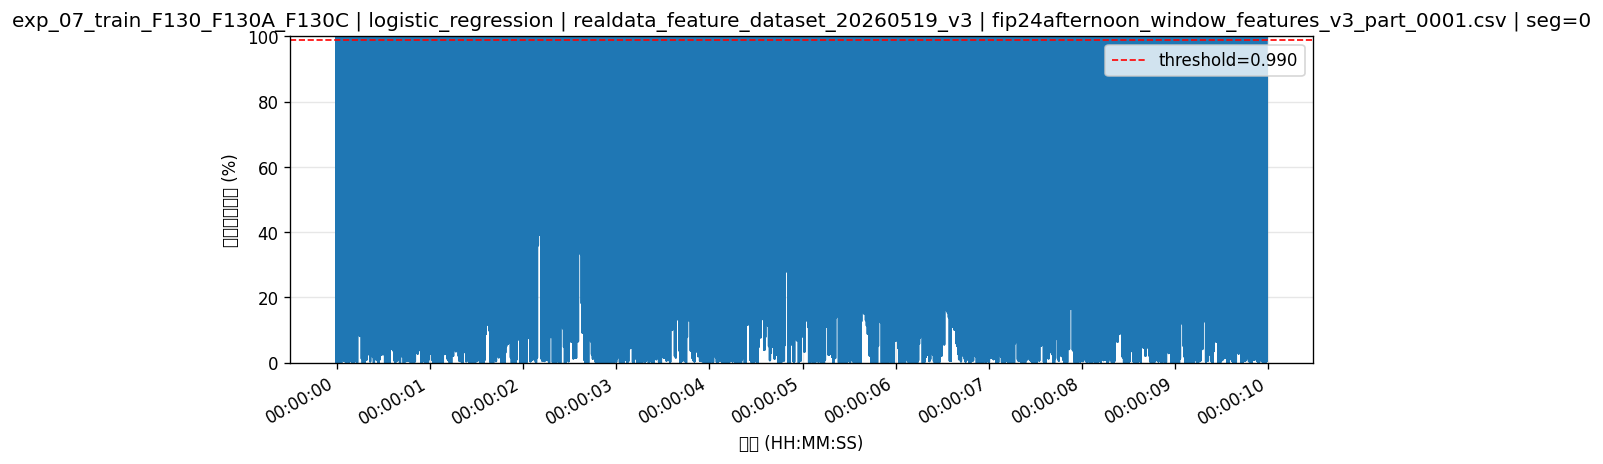

C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\1756757628.py:39: UserWarning: Glyph 26029 (\N{CJK UNIFIED IDEOGRAPH-65AD}) missing from font(s) DejaVu Sans.
  fig.savefig(out_png, bbox_inches='tight')
C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\1756757628.py:39: UserWarning: Glyph 19997 (\N{CJK UNIFIED IDEOGRAPH-4E1D}) missing from font(s) DejaVu Sans.
  fig.savefig(out_png, bbox_inches='tight')
C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\1756757628.py:39: UserWarning: Glyph 30097 (\N{CJK UNIFIED IDEOGRAPH-7591}) missing from font(s) DejaVu Sans.
  fig.savefig(out_png, bbox_inches='tight')
C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\1756757628.py:39: UserWarning: Glyph 20284 (\N{CJK UNIFIED IDEOGRAPH-4F3C}) missing from font(s) DejaVu Sans.
  fig.savefig(out_png, bbox_inches='tight')
C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\1756757628.py:39: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  fig.savefig(out_png, bbox_i

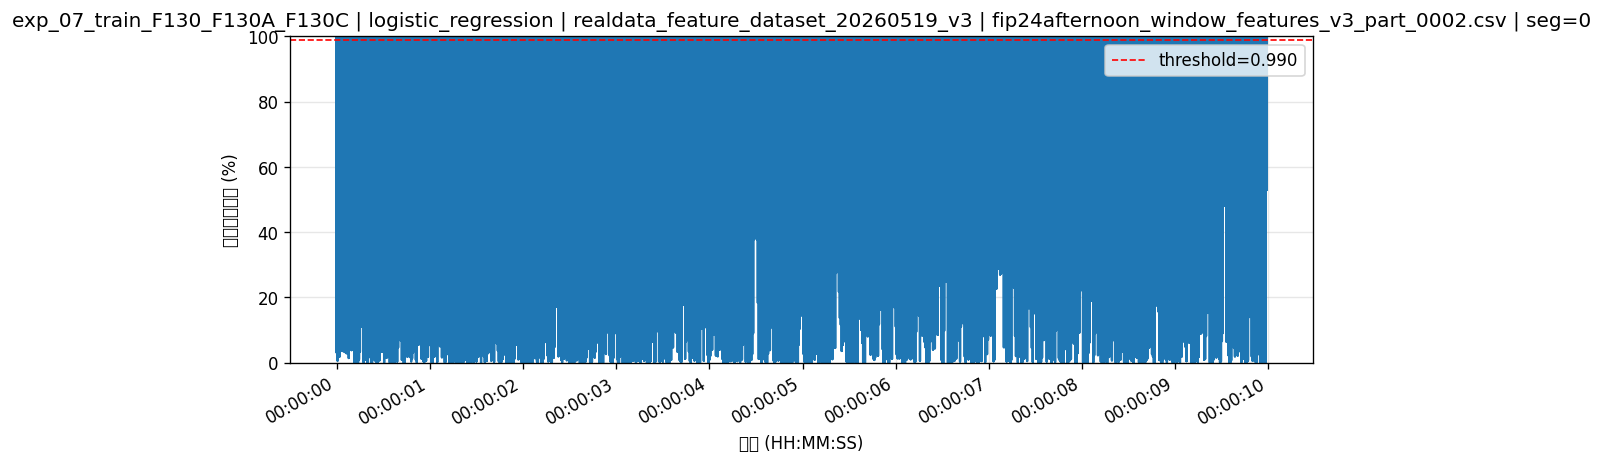

C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\1756757628.py:39: UserWarning: Glyph 26029 (\N{CJK UNIFIED IDEOGRAPH-65AD}) missing from font(s) DejaVu Sans.
  fig.savefig(out_png, bbox_inches='tight')
C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\1756757628.py:39: UserWarning: Glyph 19997 (\N{CJK UNIFIED IDEOGRAPH-4E1D}) missing from font(s) DejaVu Sans.
  fig.savefig(out_png, bbox_inches='tight')
C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\1756757628.py:39: UserWarning: Glyph 30097 (\N{CJK UNIFIED IDEOGRAPH-7591}) missing from font(s) DejaVu Sans.
  fig.savefig(out_png, bbox_inches='tight')
C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\1756757628.py:39: UserWarning: Glyph 20284 (\N{CJK UNIFIED IDEOGRAPH-4F3C}) missing from font(s) DejaVu Sans.
  fig.savefig(out_png, bbox_inches='tight')
C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\1756757628.py:39: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  fig.savefig(out_png, bbox_i

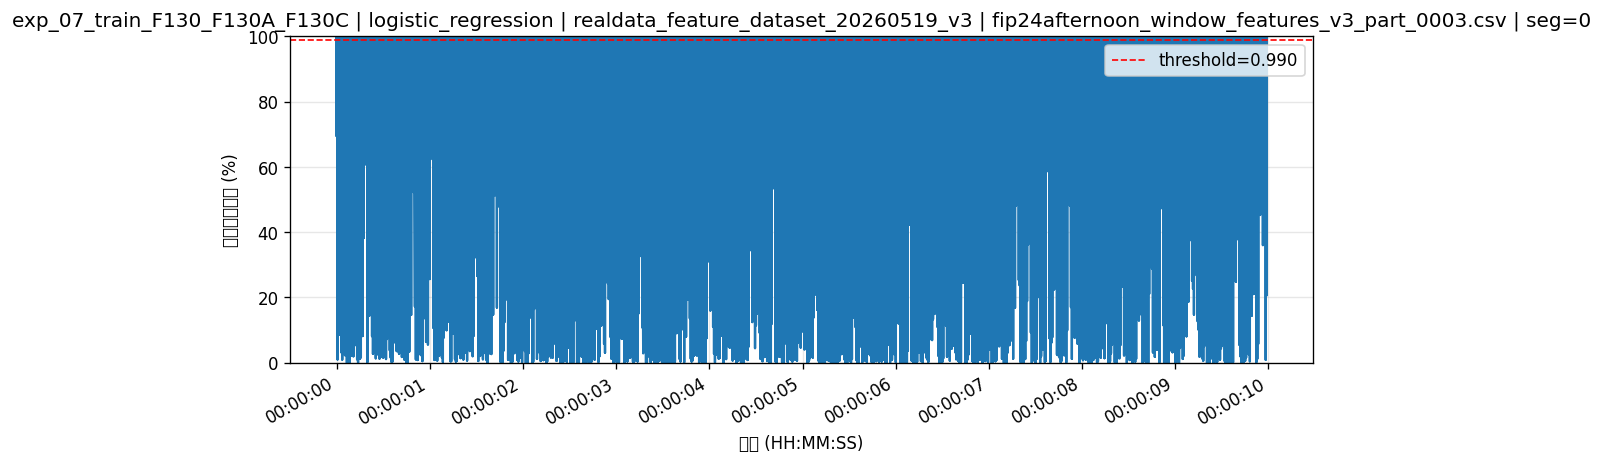

C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\1756757628.py:39: UserWarning: Glyph 26029 (\N{CJK UNIFIED IDEOGRAPH-65AD}) missing from font(s) DejaVu Sans.
  fig.savefig(out_png, bbox_inches='tight')
C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\1756757628.py:39: UserWarning: Glyph 19997 (\N{CJK UNIFIED IDEOGRAPH-4E1D}) missing from font(s) DejaVu Sans.
  fig.savefig(out_png, bbox_inches='tight')
C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\1756757628.py:39: UserWarning: Glyph 30097 (\N{CJK UNIFIED IDEOGRAPH-7591}) missing from font(s) DejaVu Sans.
  fig.savefig(out_png, bbox_inches='tight')
C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\1756757628.py:39: UserWarning: Glyph 20284 (\N{CJK UNIFIED IDEOGRAPH-4F3C}) missing from font(s) DejaVu Sans.
  fig.savefig(out_png, bbox_inches='tight')
C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\1756757628.py:39: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  fig.savefig(out_png, bbox_i

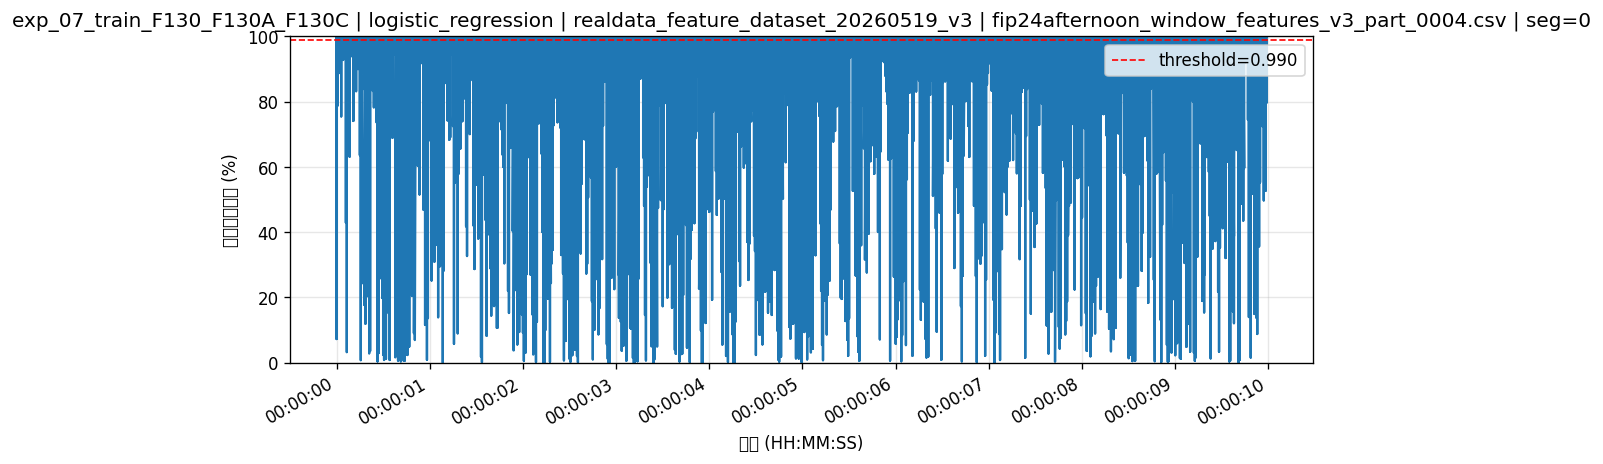

C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\1756757628.py:39: UserWarning: Glyph 26029 (\N{CJK UNIFIED IDEOGRAPH-65AD}) missing from font(s) DejaVu Sans.
  fig.savefig(out_png, bbox_inches='tight')
C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\1756757628.py:39: UserWarning: Glyph 19997 (\N{CJK UNIFIED IDEOGRAPH-4E1D}) missing from font(s) DejaVu Sans.
  fig.savefig(out_png, bbox_inches='tight')
C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\1756757628.py:39: UserWarning: Glyph 30097 (\N{CJK UNIFIED IDEOGRAPH-7591}) missing from font(s) DejaVu Sans.
  fig.savefig(out_png, bbox_inches='tight')
C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\1756757628.py:39: UserWarning: Glyph 20284 (\N{CJK UNIFIED IDEOGRAPH-4F3C}) missing from font(s) DejaVu Sans.
  fig.savefig(out_png, bbox_inches='tight')
C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\1756757628.py:39: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  fig.savefig(out_png, bbox_i

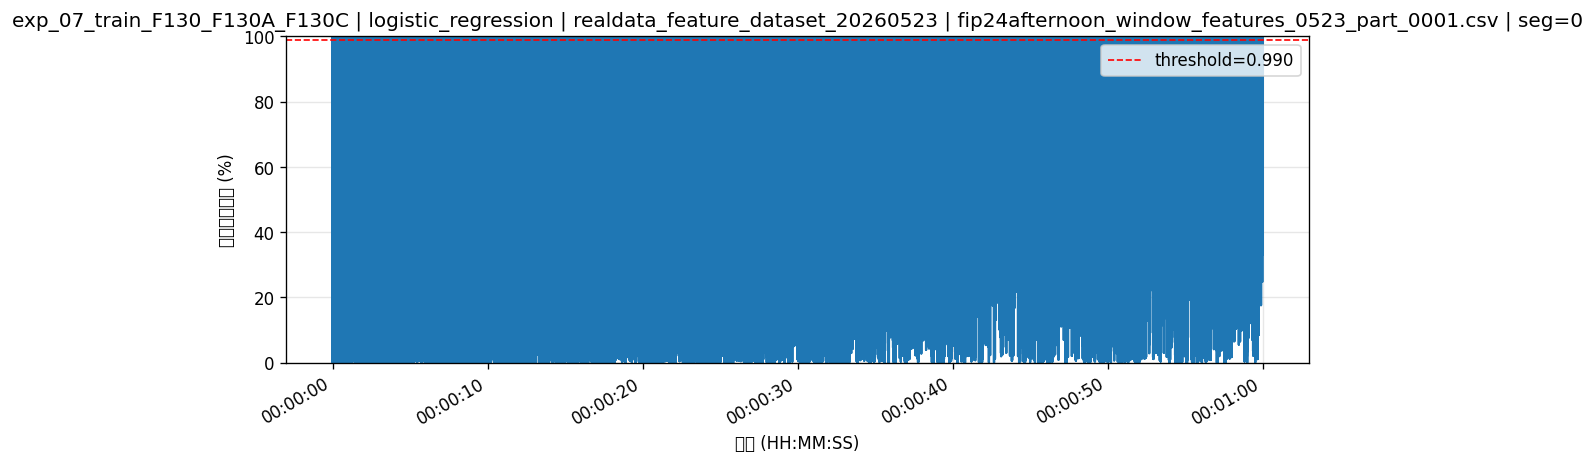

C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\1756757628.py:39: UserWarning: Glyph 26029 (\N{CJK UNIFIED IDEOGRAPH-65AD}) missing from font(s) DejaVu Sans.
  fig.savefig(out_png, bbox_inches='tight')
C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\1756757628.py:39: UserWarning: Glyph 19997 (\N{CJK UNIFIED IDEOGRAPH-4E1D}) missing from font(s) DejaVu Sans.
  fig.savefig(out_png, bbox_inches='tight')
C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\1756757628.py:39: UserWarning: Glyph 30097 (\N{CJK UNIFIED IDEOGRAPH-7591}) missing from font(s) DejaVu Sans.
  fig.savefig(out_png, bbox_inches='tight')
C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\1756757628.py:39: UserWarning: Glyph 20284 (\N{CJK UNIFIED IDEOGRAPH-4F3C}) missing from font(s) DejaVu Sans.
  fig.savefig(out_png, bbox_inches='tight')
C:\Users\QiGh\AppData\Local\Temp\ipykernel_45764\1756757628.py:39: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  fig.savefig(out_png, bbox_i

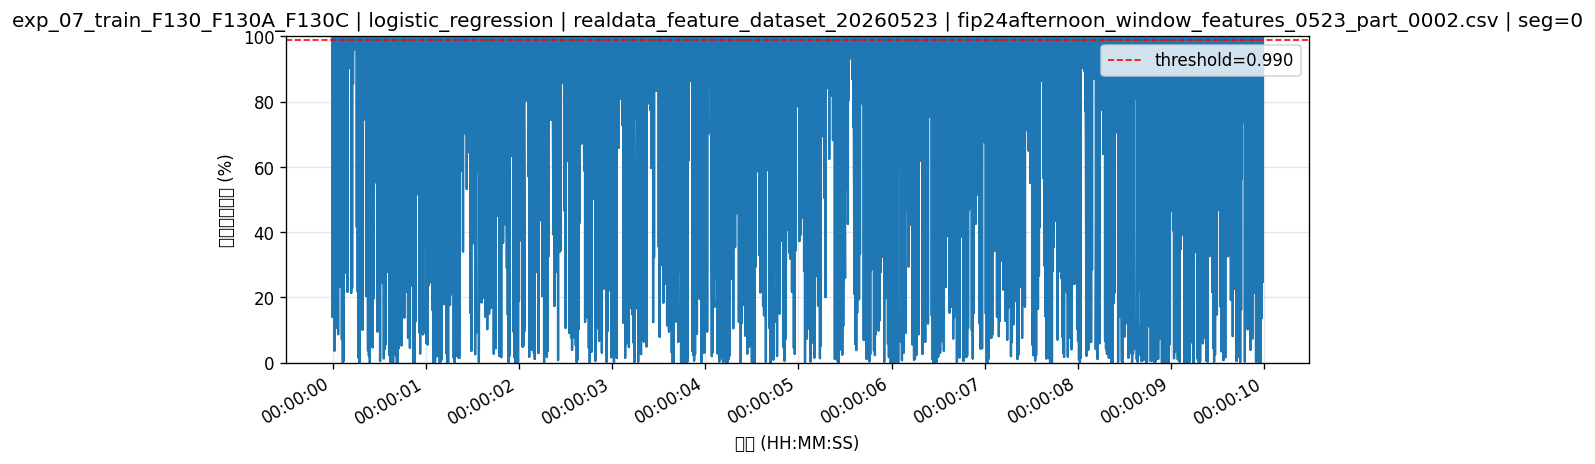

saved plots = 6
plot dir    = E:\codes\ZZ-BK\outputs\realdata_prediction_cross_condition\plots_logistic_regression


In [8]:
# 按连续时间段绘制概率曲线
plot_root = OUTPUT_DIR / f'plots_{MODEL_TYPE}'
plot_root.mkdir(parents=True, exist_ok=True)
plot_count = 0

for (exp_name, feature_dir_name, feature_file), sub in pred_df.groupby(['experiment', 'feature_dir', 'feature_file']):
    sub = sub.copy().sort_values(['window_start_datetime', 'window_id']).reset_index(drop=True)
    ts = pd.to_datetime(sub['window_start_datetime'], errors='coerce')
    valid = ts.notna()
    if not valid.any():
        print(f'[SKIP PLOT] no valid datetime: {exp_name} | {feature_dir_name} | {feature_file}')
        continue

    sub = sub.loc[valid].copy()
    ts = pd.to_datetime(sub['window_start_datetime'])
    sub['segment_id'] = split_continuous_segments(ts, gap_seconds=CONTINUITY_GAP_SECONDS).values

    for segment_id, g in sub.groupby('segment_id'):
        g = g.sort_values('window_start_datetime')
        if len(g) < 2:
            continue

        fig, ax = plt.subplots(figsize=(11, 4))
        x = pd.to_datetime(g['window_start_datetime'])
        y = g['prob_pos_pct']
        th = float(g['threshold_in_use'].iloc[0])
        ax.plot(x, y, lw=1.4)
        ax.axhline(th * 100.0, color='r', ls='--', lw=1.0, label=f'threshold={th:.3f}')
        ax.set_ylim(0, 100)
        ax.set_xlabel('时间 (HH:MM:SS)')
        ax.set_ylabel('断丝疑似概率 (%)')
        ax.set_title(f'{exp_name} | {MODEL_TYPE} | {feature_dir_name} | {feature_file} | seg={int(segment_id)}')
        ax.grid(alpha=0.3)
        ax.legend(loc='upper right')
        fig.autofmt_xdate()

        safe_file = re.sub(r'[^0-9A-Za-z._-]+', '_', feature_file)
        out_png = plot_root / f'{exp_name}__{feature_dir_name}__{safe_file}__seg{int(segment_id):03d}.png'
        fig.savefig(out_png, bbox_inches='tight')
        plt.show()
        plt.close(fig)
        plot_count += 1

print('saved plots =', plot_count)
print('plot dir    =', plot_root)


## 使用说明

1. 在“用户配置区”修改 `FEATURE_DIRS`、`MODEL_TYPE`、`EXPERIMENTS`、`USE_TRAINED_THRESHOLD`、`PROB_THRESHOLD`。
2. 顺序执行全部单元格。
3. 输出内容：
- `outputs/realdata_prediction_cross_condition/predictions_<model_type>.csv`
- `outputs/realdata_prediction_cross_condition/summary_<model_type>.csv`
- `outputs/realdata_prediction_cross_condition/plots_<model_type>/*.png`


## 附加预测：`dataset_build_260518_features_gpu`

本节使用当前已选实验组与模型，对
`E:\\codes\\ZZ-BK\\outputs\\dataset_build_260518_features_gpu`
中的 `*_features.csv` 样本执行标签预测。

In [23]:
# 附加预测目录（可按需修改）
EXTRA_FEATURE_ROOT = PROJECT_ROOT / r"outputs\\dataset_build_260518_features_gpu"
extra_files = sorted(EXTRA_FEATURE_ROOT.glob('*_features.csv'))
print('EXTRA_FEATURE_ROOT =', EXTRA_FEATURE_ROOT)
print('extra feature files =', len(extra_files))
for p in extra_files[:20]:
    print('  -', p.name)


EXTRA_FEATURE_ROOT = E:\codes\ZZ-BK\outputs\dataset_build_260518_features_gpu
extra feature files = 12
  - BK14_f130_test_features.csv
  - BK14_f130_train_features.csv
  - BK14_f130a_test_features.csv
  - BK14_f130a_train_features.csv
  - BK14_f130c_test_features.csv
  - BK14_f130c_train_features.csv
  - F130_te_features.csv
  - F130_tr_features.csv
  - F130A_te_features.csv
  - F130A_tr_features.csv
  - F130C_te_features.csv
  - F130C_tr_features.csv


In [22]:
extra_rows = []
extra_summary_rows = []

for exp_name in experiments:
    exp_dir = MODEL_ROOT / exp_name
    selected_features = load_selected_features(exp_dir)
    model, _ = load_model(exp_dir, MODEL_TYPE)
    trained_threshold = load_trained_threshold(exp_dir, MODEL_TYPE)
    if USE_TRAINED_THRESHOLD and trained_threshold is not None:
        threshold_in_use = float(trained_threshold)
        threshold_source = 'trained'
    else:
        threshold_in_use = float(PROB_THRESHOLD)
        threshold_source = 'manual'

    print('\n' + '-' * 88)
    print(f'[EXTRA] Experiment={exp_name}, threshold={threshold_in_use:.6f} ({threshold_source})')

    for feature_csv in extra_files:
        df = pd.read_csv(feature_csv)
        missing = [c for c in selected_features if c not in df.columns]
        if missing:
            print(f'  [SKIP] {feature_csv.name}: missing features -> {missing}')
            continue

        # 保持特征顺序与训练完全一致
        x = df.loc[:, selected_features].apply(pd.to_numeric, errors='coerce')
        prob_pos = model.predict_proba(x)[:, 1]
        pred = (prob_pos >= threshold_in_use).astype(int)

        ts = build_time_series(df)
        out = pd.DataFrame({
            'experiment': exp_name,
            'model_type': MODEL_TYPE,
            'feature_file': feature_csv.name,
            'source_file_name': df.get('source_file_name', ''),
            'window_id': df.get('window_id', np.arange(len(df))),
            'window_start_datetime': ts,
            'prob_pos': prob_pos,
            'prob_pos_pct': prob_pos * 100.0,
            'pred_label': pred,
            'threshold_in_use': threshold_in_use,
            'threshold_source': threshold_source,
        })

        n_total = int(len(out))
        n_pos = int((out['pred_label'] == 1).sum())
        n_neg = n_total - n_pos
        print(f'  {feature_csv.name}: pos={n_pos}, neg={n_neg}, total={n_total}')

        extra_rows.append(out)
        extra_summary_rows.append({
            'experiment': exp_name,
            'model_type': MODEL_TYPE,
            'feature_file': feature_csv.name,
            'positive_count': n_pos,
            'negative_count': n_neg,
            'total_count': n_total,
            'threshold': threshold_in_use,
            'threshold_source': threshold_source,
        })

if not extra_rows:
    print('[EXTRA] 没有生成预测结果，请检查输入目录或特征列一致性。')
else:
    extra_pred_df = pd.concat(extra_rows, ignore_index=True)
    extra_summary_df = pd.DataFrame(extra_summary_rows)
    extra_out_dir = OUTPUT_DIR / 'extra_dataset_build_260518_features_gpu'
    extra_out_dir.mkdir(parents=True, exist_ok=True)
    extra_pred_csv = extra_out_dir / f'predictions_{MODEL_TYPE}.csv'
    extra_summary_csv = extra_out_dir / f'summary_{MODEL_TYPE}.csv'
    extra_pred_df.to_csv(extra_pred_csv, index=False, encoding='utf-8-sig')
    extra_summary_df.to_csv(extra_summary_csv, index=False, encoding='utf-8-sig')
    print('saved:', extra_pred_csv)
    print('saved:', extra_summary_csv)
    display(extra_summary_df.head(50))



----------------------------------------------------------------------------------------
[EXTRA] Experiment=exp_07_train_F130_F130A_F130C, threshold=0.990000 (manual)
  BK14_f130_test_features.csv: pos=109, neg=0, total=109
  BK14_f130_train_features.csv: pos=260, neg=4, total=264
  BK14_f130a_test_features.csv: pos=1315, neg=25, total=1340
  BK14_f130a_train_features.csv: pos=3064, neg=76, total=3140
  BK14_f130c_test_features.csv: pos=124, neg=6, total=130
  BK14_f130c_train_features.csv: pos=290, neg=20, total=310
  F130_te_features.csv: pos=0, neg=109, total=109
  F130_tr_features.csv: pos=0, neg=264, total=264
  F130A_te_features.csv: pos=0, neg=1340, total=1340
  F130A_tr_features.csv: pos=0, neg=3140, total=3140
  F130C_te_features.csv: pos=0, neg=130, total=130
  F130C_tr_features.csv: pos=0, neg=310, total=310
saved: E:\codes\ZZ-BK\outputs\realdata_prediction_cross_condition\extra_dataset_build_260518_features_gpu\predictions_logistic_regression.csv
saved: E:\codes\ZZ-BK\outp

,experiment,model_type,feature_file,positive_count,negative_count,total_count,threshold,threshold_source
0,exp_07_train_F130_F130A_F130C,logistic_regression,BK14_f130_test_features.csv,109,0,109,0.99,manual
1,exp_07_train_F130_F130A_F130C,logistic_regression,BK14_f130_train_features.csv,260,4,264,0.99,manual
2,exp_07_train_F130_F130A_F130C,logistic_regression,BK14_f130a_test_features.csv,1315,25,1340,0.99,manual
3,exp_07_train_F130_F130A_F130C,logistic_regression,BK14_f130a_train_features.csv,3064,76,3140,0.99,manual
4,exp_07_train_F130_F130A_F130C,logistic_regression,BK14_f130c_test_features.csv,124,6,130,0.99,manual
5,exp_07_train_F130_F130A_F130C,logistic_regression,BK14_f130c_train_features.csv,290,20,310,0.99,manual
6,exp_07_train_F130_F130A_F130C,logistic_regression,F130_te_features.csv,0,109,109,0.99,manual
7,exp_07_train_F130_F130A_F130C,logistic_regression,F130_tr_features.csv,0,264,264,0.99,manual
8,exp_07_train_F130_F130A_F130C,logistic_regression,F130A_te_features.csv,0,1340,1340,0.99,manual
9,exp_07_train_F130_F130A_F130C,logistic_regression,F130A_tr_features.csv,0,3140,3140,0.99,manual
